# Actividad 1. Interpretabilidad de modelos 

## Dataset utilizado: Data Science Salaries 2023
### Link de descarga: https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023

### Alumna: Tatiana Duran - a2521

##### ¿Qué representa cada columna del dataset?
work_year: The year the salary was paid.

experience_level: The experience level in the job during the year

employment_type: The type of employment for the role

job_title: The role worked in during the year.

salary: The total gross salary amount paid.

salary_currency: The currency of the salary paid as an ISO 4217 currency code.

salaryinusd: The salary in USD

employee_residence: Employee's primary country of residence in during the work year as an ISO 3166 country code.

remote_ratio: The overall amount of work done remotely

company_location: The country of the employer's main office or contracting branch

company_size: The median number of people that worked for the company during the year

### Descarga del dataset

In [1]:
import kagglehub
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(DATA_DIR.resolve())

# Download latest version
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")

print("Path to dataset files:", path)

Path to dataset files: C:\Proyectos\AD2\Analisis_de_datos_II_actividades\Actividad 1\data\datasets\arnabchaki\data-science-salaries-2023\versions\1


In [3]:
df= pd.read_csv(Path(path) / "ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [5]:
target="salary"

X=df.drop(columns=[target])
y=df[target]

categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(include=["int64"]).columns

In [42]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


### EDA básico

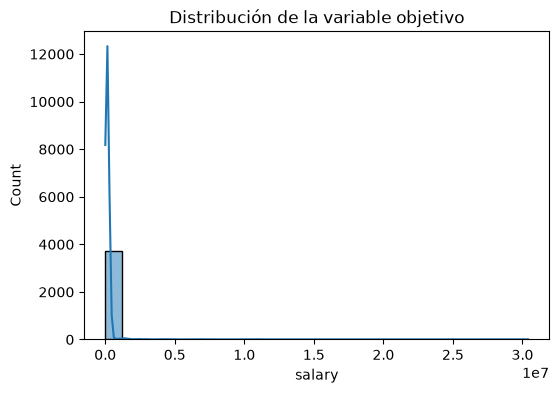

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=25, kde=True)
plt.title("Distribución de la variable objetivo")
plt.show()

Reducimos el eje y para ver hacer zoom sobre la distribución

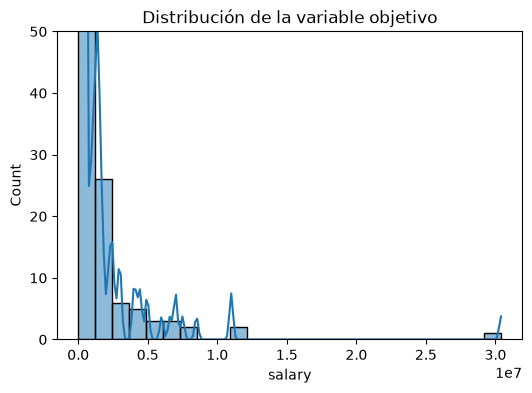

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=25, kde=True)
plt.title("Distribución de la variable objetivo")
plt.ylim(0, 50)
plt.show()

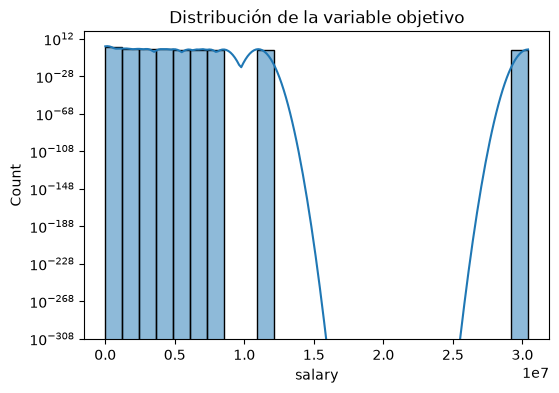

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=25, kde=True)
plt.title("Distribución de la variable objetivo")
plt.yscale("log")
plt.show()

In [7]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

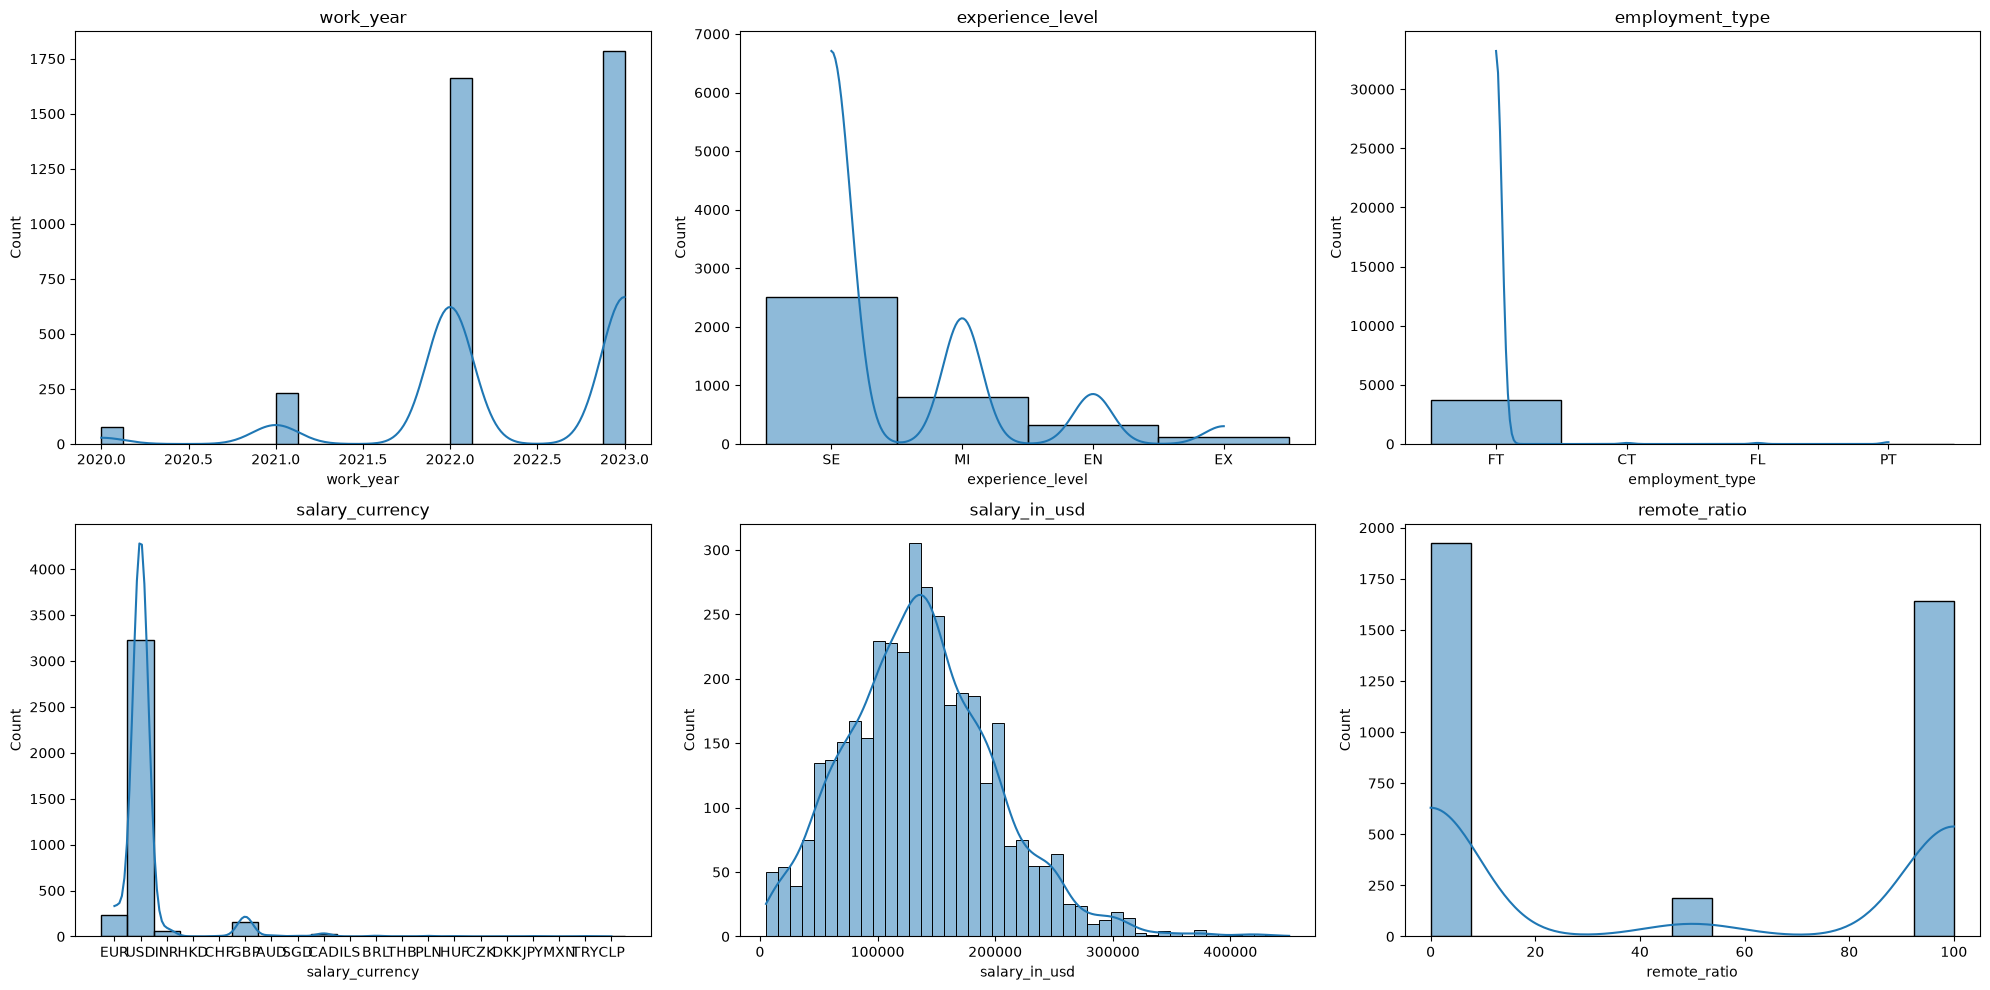

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))

cols = ['work_year', 'experience_level', 'employment_type',
       'salary_currency', 'salary_in_usd',
       'remote_ratio']

for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()

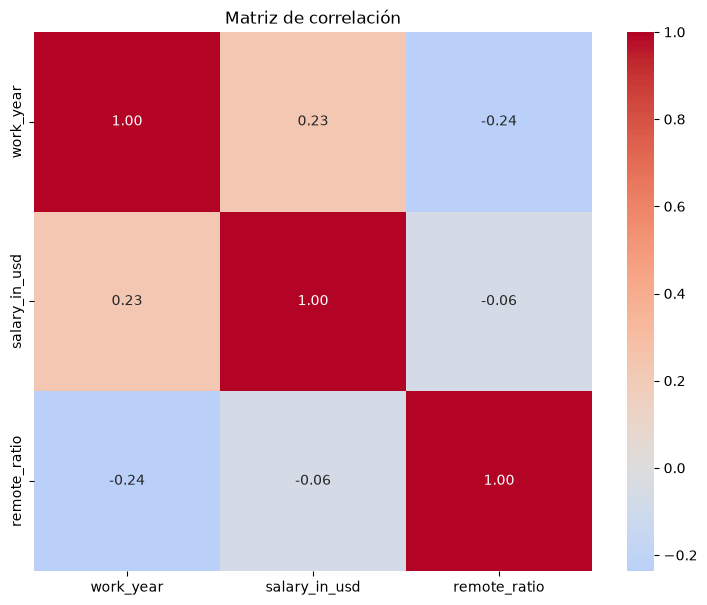

In [12]:
plt.figure(figsize=(9,7))

sns.heatmap(
    X[numeric_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

Observaciones

Con respecto a la variable target se puede observar que tiene mucho sesgo, por esta razón intenté profundizar en cómo era la distribución utlizando límite en el eje y o pasando a escalan logarítmica.

La matriz de correlación muestra relaciones entre work_year y salary_in_usd aunque algo débiles por ser 0.23.


### Entrenamiento de Random Forest Regressor para predecir el salario

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [14]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__experience_level_EN', 'cat__experience_level_EX',
       'cat__experience_level_MI', 'cat__experience_level_SE',
       'cat__employment_type_CT', 'cat__employment_type_FL',
       'cat__employment_type_FT', 'cat__employment_type_PT',
       'cat__job_title_3D Computer Vision Researcher',
       'cat__job_title_AI Developer', 'cat__job_title_AI Scientist',
       'cat__job_title_Analytics Engineer',
       'cat__job_title_Applied Data Scientist',
       'cat__job_title_Applied Machine Learning Engineer',
       'cat__job_title_Applied Machine Learning Scientist',
       'cat__job_title_Applied Scientist',
       'cat__job_title_Azure Data Engineer', 'cat__job_title_BI Analyst',
       'cat__job_title_BI Data Analyst',
       'cat__job_title_BI Data Engineer', 'cat__job_title_BI Developer',
       'cat__job_title_Big Data Architect',
       'cat__job_title_Big Data Engineer',
       'cat__job_title_Business Data Analyst',
       'cat__job_title_Business Intelligence Enginee

In [15]:
feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]
feature_names_clean

['experience_level_EN',
 'experience_level_EX',
 'experience_level_MI',
 'experience_level_SE',
 'employment_type_CT',
 'employment_type_FL',
 'employment_type_FT',
 'employment_type_PT',
 'job_title_3D Computer Vision Researcher',
 'job_title_AI Developer',
 'job_title_AI Scientist',
 'job_title_Analytics Engineer',
 'job_title_Applied Data Scientist',
 'job_title_Applied Machine Learning Engineer',
 'job_title_Applied Machine Learning Scientist',
 'job_title_Applied Scientist',
 'job_title_Azure Data Engineer',
 'job_title_BI Analyst',
 'job_title_BI Data Analyst',
 'job_title_BI Data Engineer',
 'job_title_BI Developer',
 'job_title_Big Data Architect',
 'job_title_Big Data Engineer',
 'job_title_Business Data Analyst',
 'job_title_Business Intelligence Engineer',
 'job_title_Cloud Data Architect',
 'job_title_Cloud Data Engineer',
 'job_title_Cloud Database Engineer',
 'job_title_Compliance Data Analyst',
 'job_title_Computer Vision Engineer',
 'job_title_Computer Vision Software E

In [16]:
for name in feature_names_clean:
    if name.__contains__("salary_in_usd"):
        print(name)

salary_in_usd


In [17]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [18]:
y_pred = model.predict(X_test_trans)

Text(0.5, 0, 'Dato real')

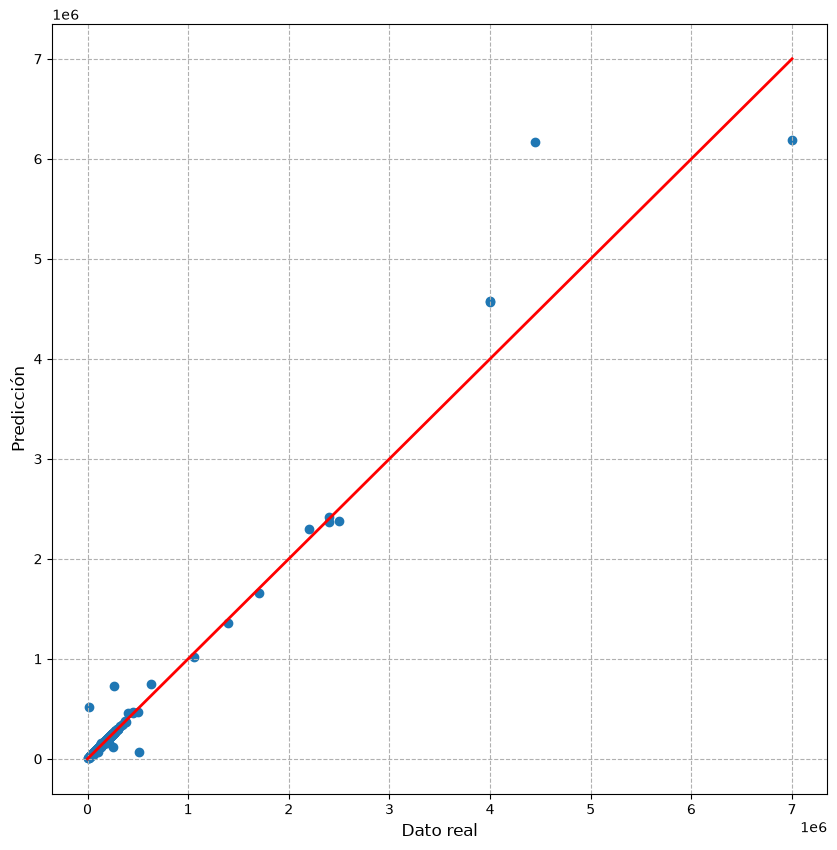

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10, 10))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 7000000], [0, 7000000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)

#### Para ver mejor los datos que se encuentran entre 0 y 1000000 se corta el gráfico

(0.0, 1000000.0)

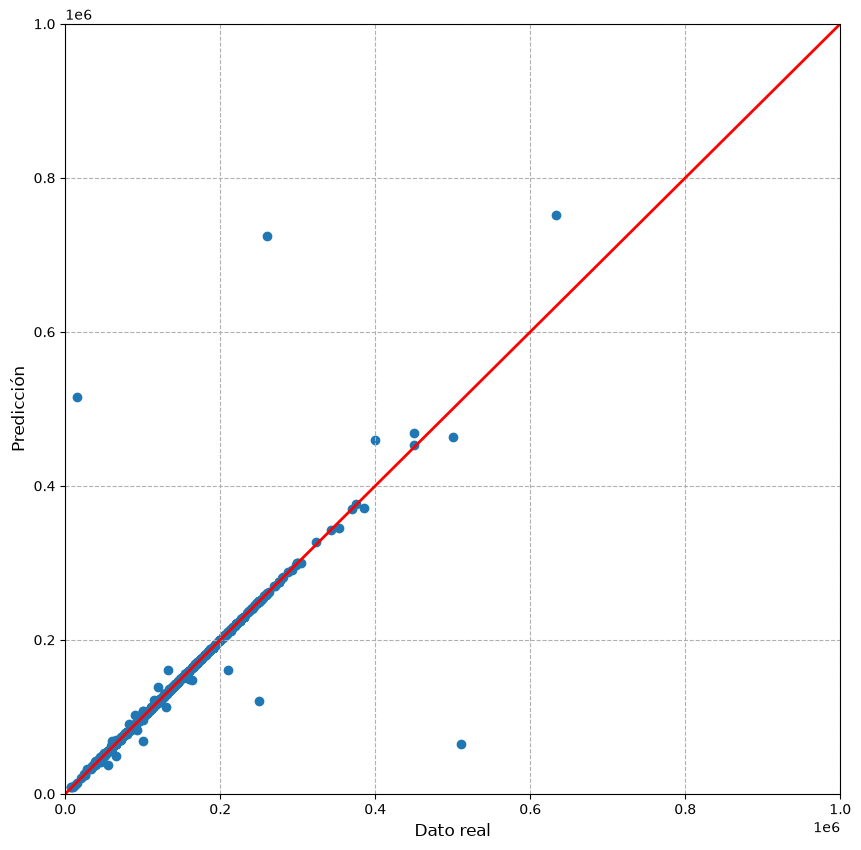

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10, 10))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 1000000], [0, 1000000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)

ax.set_xlim(0, 1000000)
ax.set_ylim(0, 1000000)

#### Hacemos un poco más de zoom en el gráfico

(0.0, 600000.0)

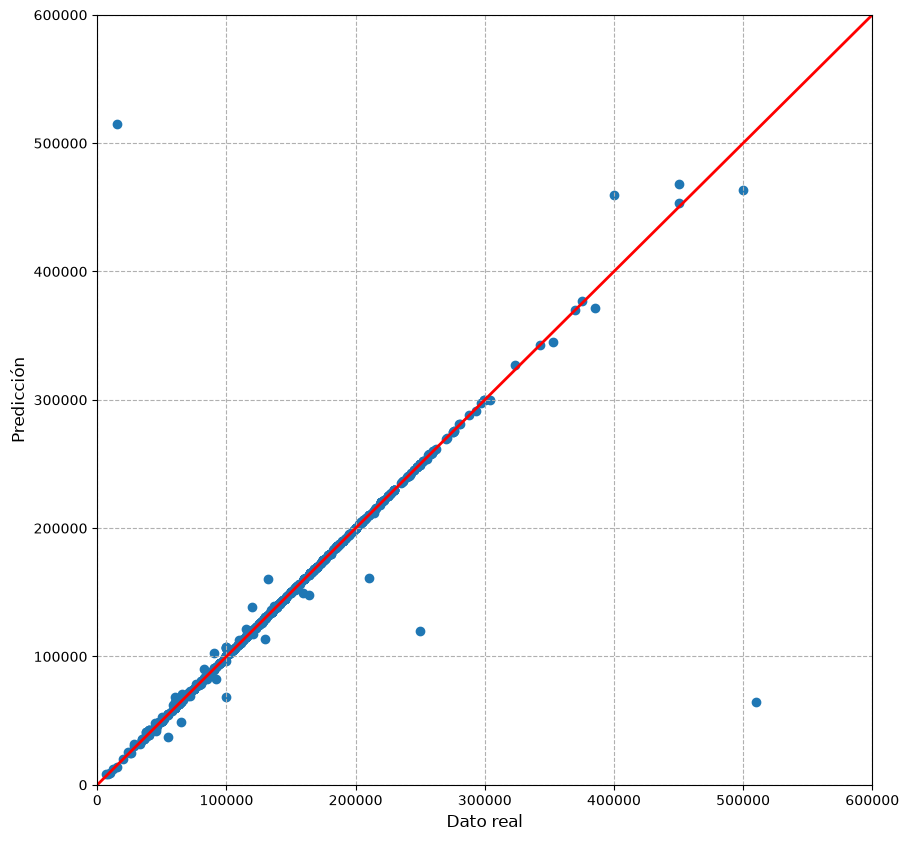

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10, 10))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 600000], [0, 600000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)

ax.set_xlim(0, 600000)
ax.set_ylim(0, 600000)

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

R²: 0.959
MAE (Error Absoluto Medio): 8394.819


Observaciones

R2 y MAE son muy buenos como para predecir un salario a partir de variables como puesto, experiencia y ubicación.

Se puede sospechar data leakage con las variables salary_in_usd y salary_currency

### Permutation Feature Importance (PFI)

In [23]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [24]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

In [25]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)
pfi

,feature,importance,std
4,salary_currency,5.118512e+00,2.235935e-01
5,salary_in_usd,2.219314e+00,8.379143e-02
1,experience_level,9.249288e-04,9.625991e-04
7,remote_ratio,2.628667e-04,3.034260e-04
3,job_title,9.985694e-05,3.252368e-04
9,company_size,5.779446e-05,4.676634e-05
2,employment_type,2.857857e-11,6.783208e-11
0,work_year,-2.471930e-04,2.063907e-04
6,employee_residence,-5.680592e-03,3.107758e-04
8,company_location,-8.493750e-03,3.311355e-04


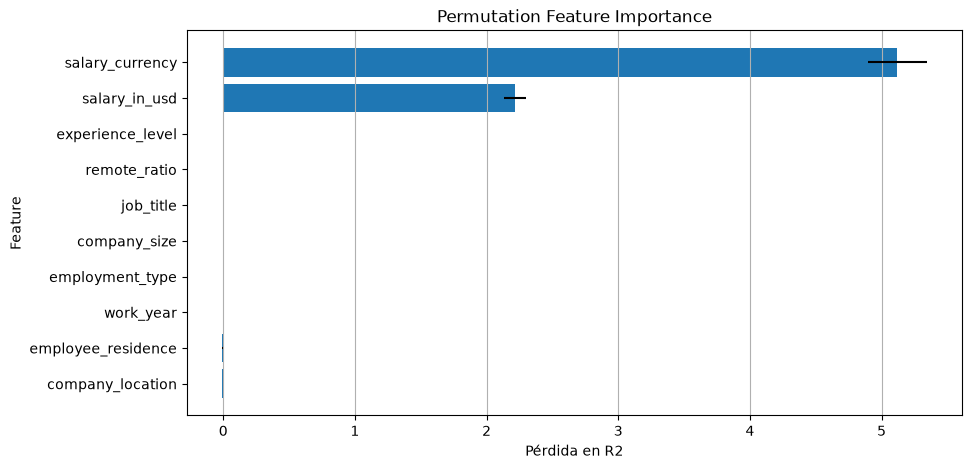

In [26]:
plt.figure(figsize=(10, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

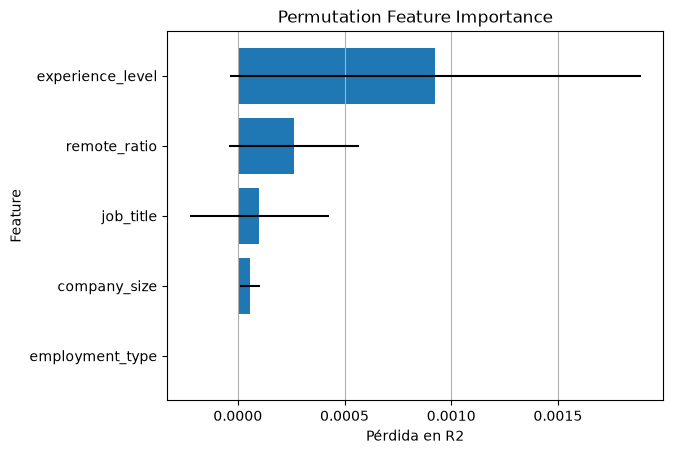

In [27]:
mask = (pfi["importance"] > 0) & (pfi["importance"] < 2)


plt.barh(
    pfi[mask]["feature"],
    pfi[mask]["importance"],
    xerr=pfi[mask]["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

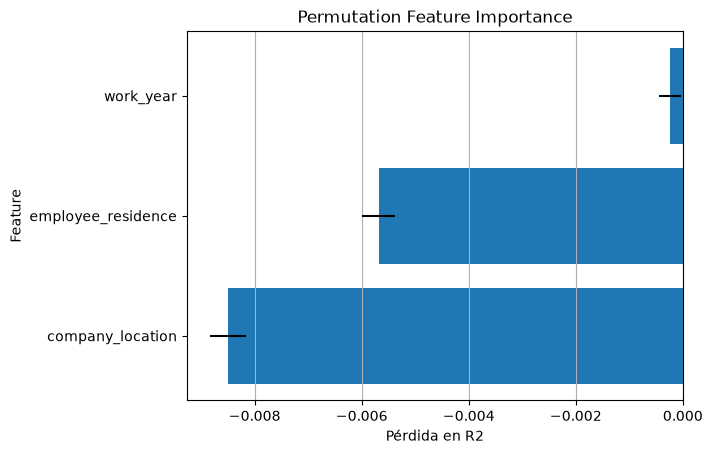

In [28]:
plt.barh(
    pfi[pfi["importance"] < 0]["feature"],
    pfi[pfi["importance"] < 0]["importance"],
    xerr=pfi[pfi["importance"] < 0]["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

Observaciones

Se puede confirmar data leakage ya que justo las variables de las que sospechamos al ser permutadas el modelo baja mucho su rendimiento. Y las demás variables no mueven al aguja prácticamente.

El PFI nos ayuda a confirmar lo que en el EDA no se vio a simple vista.

### PDP

#### Partial Dependence Plot con respecto a salary_in_usd

In [29]:
#features=[name for name in feature_names_clean if name.__contains__("salary_currency")]
features=["salary_in_usd"]
features

['salary_in_usd']

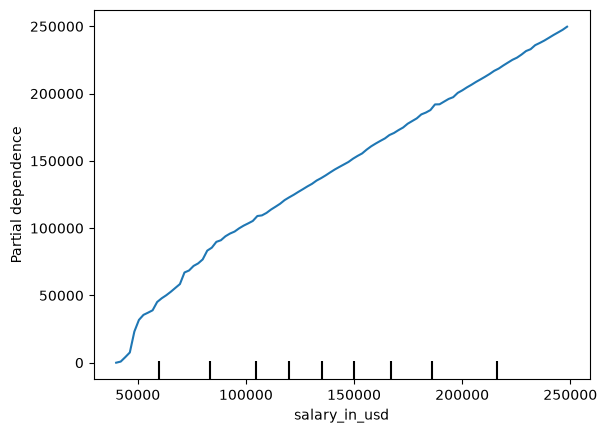

In [30]:
X_train_dense = np.asarray(X_train_trans.todense())

PartialDependenceDisplay.from_estimator(
    model,
    X_train_dense,
    features=features,
    feature_names=feature_names_clean,
    centered=True
)
plt.show()

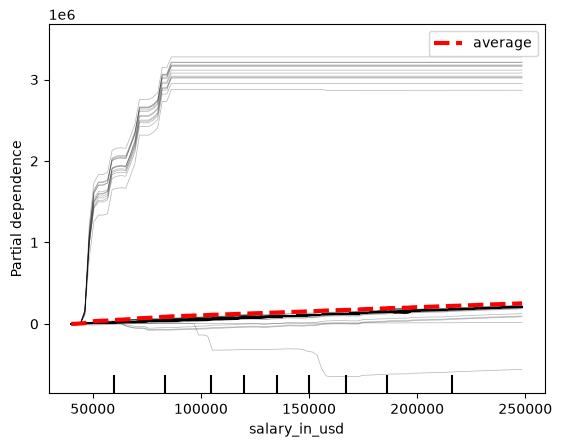

In [31]:

PartialDependenceDisplay.from_estimator(
    model,
    X_train_dense,
    features=features,
    feature_names=feature_names_clean,
    kind='both',
    centered= True,
    ice_lines_kw={"color": "black"},
    pd_line_kw={"color": "red","lw":3,'linestyle':'--'})
plt.show()

Como salary_in_usd es una variable dominante al estar tan relacionada con la target se observa una curva marcadamente creciente. Lo que continúa confirmando la dependencia entre ellas.

### ALE

In [33]:
from alibi.explainers import ALE
from alibi.explainers import plot_ale
ale = ALE(
    predictor=model.predict,
    feature_names=feature_names,
    target_names=["salary"]
)

exp = ale.explain(X_train_dense)

In [40]:
len(feature_names_clean)

260

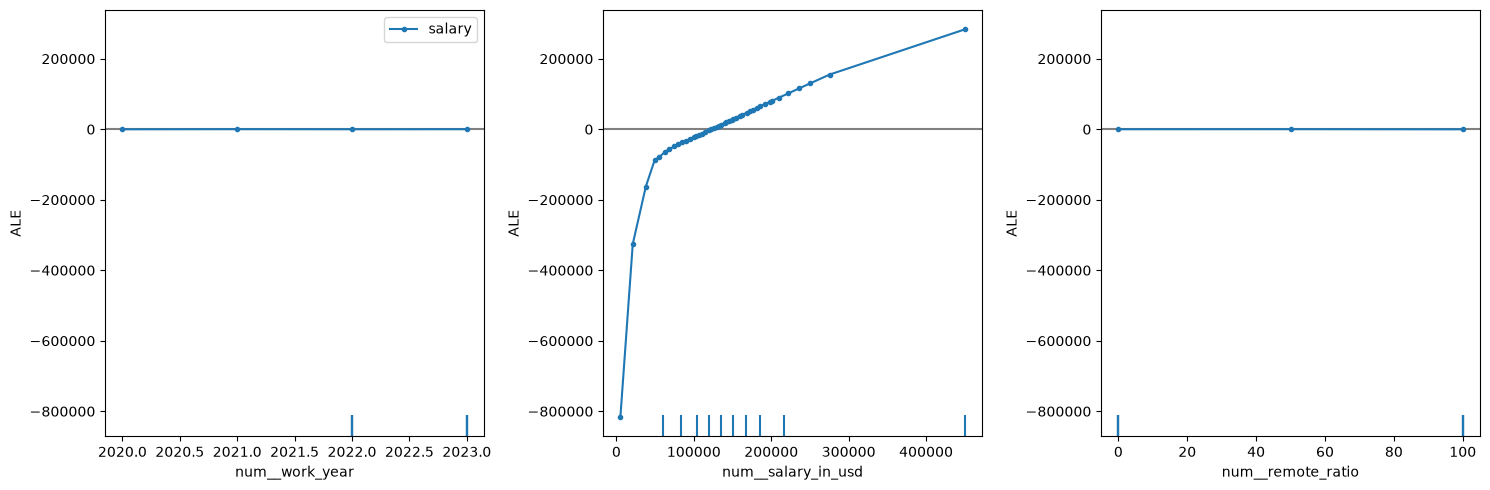

In [41]:
plot_ale(exp, features=[257,258,259], fig_kw={'figwidth':15, 'figheight': 5})
plt.show()

Si bien ALE evita promediar sobre combinaciones irreales de salary_in_usd se ve que la curva sigue siendo creciente, lo que evidencia de que el leakage domina tanto que ni corrigiendo por correlación cambia demasiado el resultado

### SHAP

In [43]:
import shap

In [58]:
X_test_dense = np.asarray(X_test_trans.todense())
explainer = shap.Explainer(model.predict, X_train_dense, feature_names=feature_names_clean)
explanation = explainer(X_test_dense)

PermutationExplainer explainer: 752it [03:10,  3.68it/s]                         


In [59]:
shap_values     = explanation.values          # los valores SHAP
expected_values = explanation.base_values     # valor base (expected value)
data            = explanation.data            # los valores originales de X
feature_names   = explanation.feature_names   # nombres de las variables

In [60]:
expected_values[0]

141959.60259999998

In [61]:
print("Observación (la primera del dataset de test):")
display(X_test.iloc[[0]])

print(f"Valor real: {y_test.iloc[0]}")
print(f"Predicción: {y_pred[0]:.2f}")

Observación (la primera del dataset de test):


,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
2148,2022,SE,FT,Machine Learning Software Engineer,USD,168000,CA,100,CA,M


Valor real: 168000
Predicción: 167453.35


In [62]:
exp_1muestra = explanation[0, :] # primera muestra, todas las features
exp_1muestra

.values =
array([ 2.03775000e-01,  6.56500000e-02,  2.01988750e+00,  1.11114500e+01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.25000000e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  5.21475000e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.71243750e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  3.03500000e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.50000000e-01,  0.00000000e+00,  2.57727500e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.12500000e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -4.12750000e-02,  9.25000000e-01,  0.00000000e+00, -1.80000000e-02,
        1.45646

In [63]:
print("Predicción (base + SHAP values):",exp_1muestra.base_values + exp_1muestra.values.sum())

Predicción (base + SHAP values): 167453.34999999974


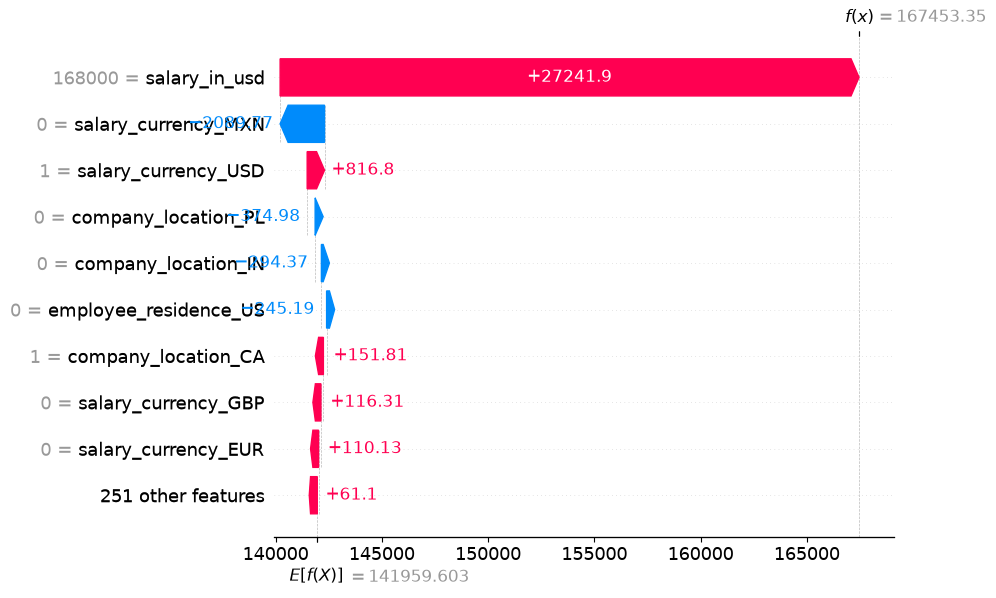

In [64]:
shap.plots.waterfall(exp_1muestra)

Como podemos observar las variables que contribuyeron más fueron las de salary_in_usd y las codificadas de salary_currency sobre todo la de USD. Esto confirma lo que vimos en el análisis global, el data leakage entre esas variables y la target.

### Auditoría

¿Qué evidencia proporcionan las técnicas de interpretabilidad?

Todas las técnicas señalan lo mismo desde ángulos distintos: salary_currency y salary_in_usd dominan el modelo. El PFI les da una pérdida de R² de 5.12 y 2.22 respectivamente, mientras que el resto de las variables (experiencia, puesto, tamaño de empresa, etc.) está en el orden de 10⁻⁴/10⁻⁵, es decir, ruido. El PDP muestra una curva marcadamente creciente de salary_in_usd, y el ALE,que corrige por correlación entre features, muestra prácticamente la misma forma, confirmando que no es un artefacto de correlación sino una relación real (aunque espuria) que el modelo aprendió. Por último, el SHAP de la muestra individual lo hace todavía más concreto: de una predicción de 167.453 con base 141.960, el aporte de salary_in_usd solo es de +27.241.9, el contribuyente individual más grande por lejos, muy por encima de cualquier otra variable.

¿El comportamiento es razonable para el problema?

No. El objetivo de negocio es predecir el salario a partir de características del puesto (experiencia, rol, ubicación, tamaño de empresa, modalidad remota). Que el modelo dependa casi exclusivamente de salary_in_usd no es razonable ni útil, porque esa variable no es un predictor genuino disponible de antemano, es prácticamente el mismo dato que el target, solo expresado en otra moneda. Un R²=0.959 en este contexto no refleja que el modelo "entendió" qué determina un salario, sino que aprendió a revertir una conversión de moneda.

¿Qué posible causa podría explicar ese comportamiento?

Data leakage: salary_in_usd es una transformación (conversión de moneda) del propio target salary.  Combinando ambas variables, el modelo tiene, de hecho, casi toda la información necesaria para predecir la target sin usar ninguna variable de negocio real.

¿Qué acción tomarían para investigarlo o corregirlo?

Excluir salary_in_usd y salary_currency de X antes de entrenar (o directamente usar salary_in_usd como variable objetivo en vez de salary, ya que es la versión comparable entre países).

Reentrenar el modelo sin esas dos columnas y comparar R²/MAE: se espera que bajen bastante, reflejando una tarea más realista.
Repetir PFI, PDP, ALE y SHAP sobre el modelo corregido, para ver si ahí sí aparecen como relevantes variables como experience_level, job_title o company_size.

Como práctica general para el futuro: antes de entrenar, revisar si alguna feature es una transformación (parcial o total) del target. Un chequeo que la matriz de correlación lineal del EDA no alcanzó a detectar, y que recién se hizo evidente con PFI.

### Se eliminan las variables salary_in_usd y salary_currency y se reentrena el modelo

In [70]:
target="salary"
dala_leakage=["salary_in_usd", "salary_currency"]

X=df.drop(columns=[target, *dala_leakage])
y=df[target]

categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(include=["int64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# Limpieza nombres de features
feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]

# Entrenamiento del modelo
model = RandomForestRegressor(random_state=42)
model.fit(X_train_trans, y_train)

y_pred = model.predict(X_test_trans)

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10, 10))

plt.scatter(y_test,y_pred)
plt.grid(True, ls='--')
plt.plot([0, 7000000], [0, 7000000], color='r', linestyle='-', linewidth=2)

plt.ylabel('Predicción',size=12)
plt.xlabel('Dato real',size=12)

# Métricas de evaluación
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

X.columns

R²: 0.598
MAE (Error Absoluto Medio): 69594.090


Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

Index(['work_year', 'remote_ratio'], dtype='object')

Ya podemos ver como el rendimiento del modelo bajó notablemente.

Ahora miremos la importancia de las variables.

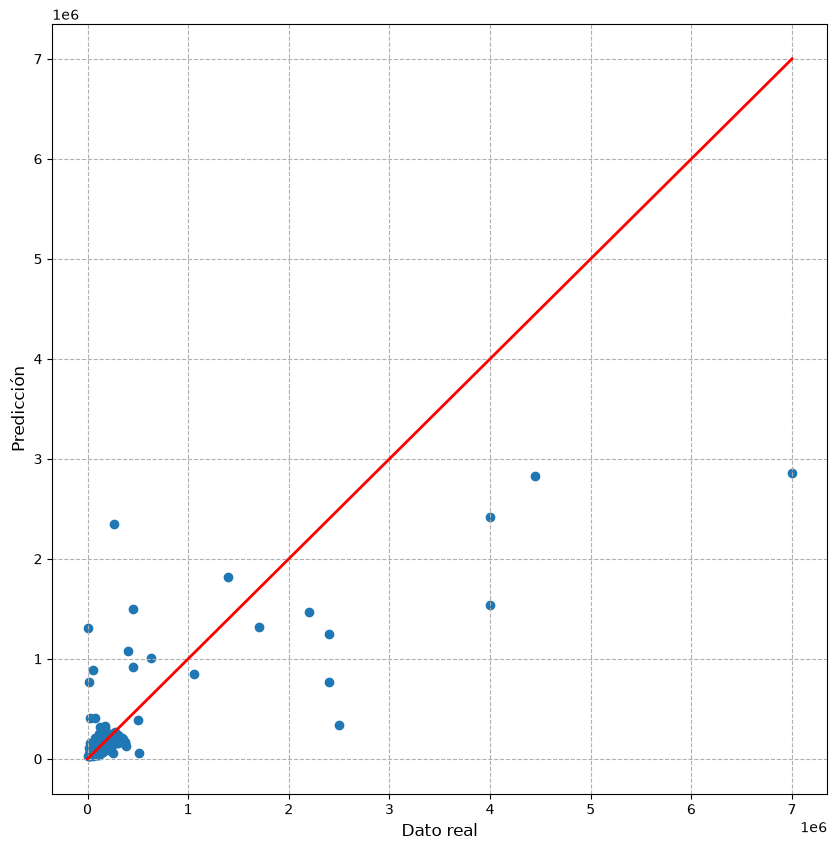

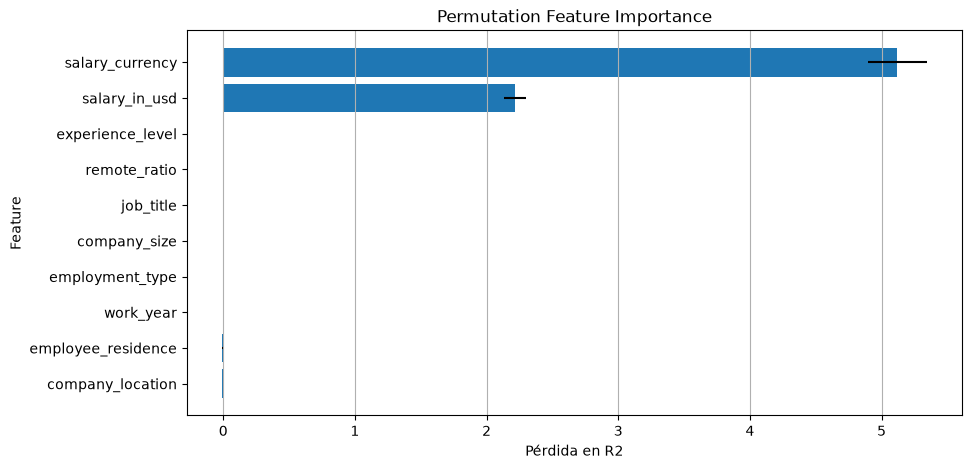

In [ ]:
model_pfi2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

result = permutation_importance(
    model_pfi2,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

plt.figure(figsize=(10, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en R2")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()